# TCGA Kidney Cancer: NSGA-II, Decision Tree, and Survival Analysis

**Notebook revision:** `2026-08-01-vectorized-pymoo-colab-fix`
This Colab notebook consumes the leakage-controlled files created by the companion preprocessing notebook and runs the primary `log2(TPM + 1)` and sensitivity `log2(CPM + 1)` branches independently.

For a candidate subset containing \(p\) genes, NSGA-II maximizes:

\[
\text{Balanced accuracy}
\qquad\text{and}\qquad
\text{Soft leanness}=\frac{1}{\sqrt{p}+1}.
\]

Because `pymoo` minimizes, the internal objectives are `1 - balanced_accuracy` and `1 - soft_leanness`. NSGA-II and final decision-tree tuning use training data only. The held-out validation cohort is evaluated once after the final tree is fixed. Overall-survival analyses use GDC clinical data and are treated as exploratory.

In [ ]:
# ============================================================
# CELL 1: INSTALL THE TWO PACKAGES NOT NORMALLY IN COLAB
# ============================================================

# scikit-learn is already installed in Colab and is intentionally not upgraded.
!pip -q install "pymoo==0.6.2" "lifelines==0.30.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2: IMPORTS, REPRODUCIBILITY, PATHS, AND SETTINGS
# ============================================================

from pathlib import Path
from itertools import combinations
from threading import Lock

import json
import math
import os
import platform
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test, multivariate_logrank_test

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.callback import Callback
from pymoo.core.problem import Problem
from pymoo.core.repair import Repair
from pymoo.core.sampling import Sampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.optimize import minimize

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# -------------------- Reproducibility --------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ---------------- Notebook revision check ----------------
NOTEBOOK_REVISION = "2026-08-01-vectorized-pymoo-colab-fix"

# -------------------- File locations ---------------------
# Set True when the preprocessing notebook wrote its outputs to Google Drive.
USE_GOOGLE_DRIVE = True

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if USE_GOOGLE_DRIVE:
    if not IN_COLAB:
        raise RuntimeError("Google Drive mounting requires Google Colab.")
    drive.mount("/content/drive")
    INPUT_DIR = Path("/content/drive/MyDrive/TCGA_Kidney_RNASeq/processed_outputs")
    OUTPUT_DIR = Path("/content/drive/MyDrive/TCGA_Kidney_RNASeq/modeling_outputs")
elif IN_COLAB:
    INPUT_DIR = Path("/content/TCGA_Kidney_RNASeq/processed_outputs")
    OUTPUT_DIR = Path("/content/TCGA_Kidney_RNASeq/modeling_outputs")
else:
    INPUT_DIR = Path.cwd() / "TCGA_Kidney_RNASeq" / "processed_outputs"
    OUTPUT_DIR = Path.cwd() / "TCGA_Kidney_RNASeq" / "modeling_outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BRANCH_FILE_MAP = {
    "primary_log2_tpm": {
        "training": "primary_log2_tpm_training.csv",
        "validation": "primary_log2_tpm_heldout_validation.csv",
    },
    "sensitivity_log2_cpm": {
        "training": "sensitivity_log2_cpm_training.csv",
        "validation": "sensitivity_log2_cpm_heldout_validation.csv",
    },
}
BRANCHES_TO_RUN = ["primary_log2_tpm", "sensitivity_log2_cpm"]

GENE_ANNOTATION_FILE = "tcga_kidney_gene_annotation.csv"
SAMPLE_METADATA_FILE = "tcga_kidney_sample_metadata_with_split.csv"

NON_GENE_COLUMNS = [
    "project_id", "class_label", "sample_id", "sample_submitter_id",
    "sample_type", "library_size_all_annotated_genes", "data_split",
]

# -------------------- NSGA-II settings --------------------
# Ten-fold CV follows the dissertation framework. For a quick code check only,
# temporarily reduce POPULATION_SIZE, N_GENERATIONS, and NSGA_CV_SPLITS.
NSGA_CV_SPLITS = 10
POPULATION_SIZE = 100
N_GENERATIONS = 100
CROSSOVER_PROBABILITY = 0.90
MUTATION_PROBABILITY_PER_GENE = 0.01

# Sparse bounds prevent empty or clinically unwieldy chromosomes.
MIN_GENES_PER_SOLUTION = 2
MAX_GENES_PER_SOLUTION = 50
INITIAL_MIN_GENES = 2
INITIAL_MAX_GENES = 20

# Chromosomes are evaluated by the vectorized pymoo Problem implementation.
# This avoids pymoo's ElementwiseProblem/elementwise_runner pathway entirely.
ENABLE_FITNESS_CACHE = True
PARETO_ACCURACY_TIE_TOLERANCE = 1e-8

# Fixed internal fitness classifier.
FITNESS_MODEL_PARAMETERS = {
    "learning_rate": 0.01,
    "max_iter": 50,
    "max_depth": 5,
    "min_samples_leaf": 10,
    "max_bins": 20,
    "l2_regularization": 0.0,
    "early_stopping": False,
    "random_state": RANDOM_SEED,
}

# ---------------- Final decision-tree settings -------------
FINAL_TREE_CV_SPLITS = 10
FINAL_TREE_PARAMETER_GRID = {
    "criterion": ["gini", "log_loss"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_leaf": [5, 10, 20],
    "min_samples_split": [10, 20],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

# -------------------- Survival settings --------------------
GDC_PROJECTS = ["TCGA-KICH", "TCGA-KIRC", "TCGA-KIRP"]
MODEL_SURVIVAL_SCOPE = "validation"  # "validation" is the conservative default.
MIN_SURVIVAL_GROUP_N = 10
MIN_SURVIVAL_GROUP_EVENTS = 3
COX_PENALIZER = 0.01

print(f"Notebook revision: {NOTEBOOK_REVISION}")
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Input directory: {INPUT_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Mounted at /content/drive
Notebook revision: 2026-08-01-vectorized-pymoo-colab-fix
Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Input directory: /content/drive/MyDrive/TCGA_Kidney_RNASeq/processed_outputs
Output directory: /content/drive/MyDrive/TCGA_Kidney_RNASeq/modeling_outputs


In [ ]:
# ============================================================
# CELL 3: LOAD AND VALIDATE THE PREPROCESSED EXPRESSION FILES
# ============================================================

def require_file(path):
    """Raise a clear error when an expected input file is absent."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n  {path}\n"
            "Run the preprocessing notebook first or change INPUT_DIR in Cell 2."
        )
    return path


# Confirm every required file before fitting any model.
required_files = [
    INPUT_DIR / GENE_ANNOTATION_FILE,
    INPUT_DIR / SAMPLE_METADATA_FILE,
]
for branch_name in BRANCHES_TO_RUN:
    required_files += [
        INPUT_DIR / BRANCH_FILE_MAP[branch_name]["training"],
        INPUT_DIR / BRANCH_FILE_MAP[branch_name]["validation"],
    ]
for path in required_files:
    require_file(path)

gene_annotation = pd.read_csv(
    INPUT_DIR / GENE_ANNOTATION_FILE,
    dtype={"gene_id": str},
).drop_duplicates("gene_id", keep="first")

sample_metadata = pd.read_csv(
    INPUT_DIR / SAMPLE_METADATA_FILE,
    dtype={"case_submitter_id": str},
).set_index("case_submitter_id")

if sample_metadata.index.duplicated().any():
    raise RuntimeError("Duplicate patient IDs were found in sample metadata.")

GENE_ID_TO_SYMBOL = (
    gene_annotation.set_index("gene_id")["gene_name"]
    .fillna("")
    .astype(str)
    .to_dict()
)


def load_expression_branch(branch_name):
    """
    Read one branch and enforce identical genes, disjoint patient sets,
    finite values, and labels known from the training cohort.
    """
    files = BRANCH_FILE_MAP[branch_name]
    training = pd.read_csv(
        INPUT_DIR / files["training"],
        index_col="case_submitter_id",
    )
    validation = pd.read_csv(
        INPUT_DIR / files["validation"],
        index_col="case_submitter_id",
    )
    training.index = training.index.astype(str)
    validation.index = validation.index.astype(str)

    if training.index.duplicated().any() or validation.index.duplicated().any():
        raise RuntimeError(f"{branch_name}: duplicate patient IDs.")
    if set(training.index) & set(validation.index):
        raise RuntimeError(f"{branch_name}: training-validation overlap.")

    missing_columns = (
        set(NON_GENE_COLUMNS) - set(training.columns)
    ) | (
        set(NON_GENE_COLUMNS) - set(validation.columns)
    )
    if missing_columns:
        raise RuntimeError(
            f"{branch_name}: missing metadata columns {sorted(missing_columns)}"
        )

    X_train = training.drop(columns=NON_GENE_COLUMNS).astype(np.float32)
    X_validation = validation.drop(columns=NON_GENE_COLUMNS).astype(np.float32)

    if not X_train.columns.equals(X_validation.columns):
        raise RuntimeError(f"{branch_name}: gene columns or order differ.")
    if X_train.isna().any().any() or X_validation.isna().any().any():
        raise RuntimeError(f"{branch_name}: missing expression values.")
    if not np.isfinite(X_train.to_numpy()).all():
        raise RuntimeError(f"{branch_name}: non-finite training values.")
    if not np.isfinite(X_validation.to_numpy()).all():
        raise RuntimeError(f"{branch_name}: non-finite validation values.")

    y_train_text = training["class_label"].astype(str)
    y_validation_text = validation["class_label"].astype(str)

    encoder = LabelEncoder()
    y_train = encoder.fit_transform(y_train_text)
    unseen = set(y_validation_text) - set(encoder.classes_)
    if unseen:
        raise RuntimeError(f"{branch_name}: unseen validation labels {sorted(unseen)}")
    y_validation = encoder.transform(y_validation_text)

    expected_train = set(
        sample_metadata.index[sample_metadata["data_split"] == "training"]
    )
    expected_validation = set(
        sample_metadata.index[sample_metadata["data_split"] == "validation"]
    )
    if set(X_train.index) != expected_train:
        raise RuntimeError(f"{branch_name}: training IDs differ from saved split.")
    if set(X_validation.index) != expected_validation:
        raise RuntimeError(f"{branch_name}: validation IDs differ from saved split.")

    smallest_class = int(pd.Series(y_train).value_counts().min())
    required_folds = max(NSGA_CV_SPLITS, FINAL_TREE_CV_SPLITS)
    if smallest_class < required_folds:
        raise RuntimeError(
            f"{branch_name}: smallest training class has {smallest_class} "
            f"patients, fewer than the requested {required_folds} folds."
        )

    print(
        f"{branch_name}: training {X_train.shape}; "
        f"validation {X_validation.shape}; classes {list(encoder.classes_)}"
    )
    return {
        "branch_name": branch_name,
        "training_data": training,
        "validation_data": validation,
        "X_train": X_train,
        "X_validation": X_validation,
        "y_train": y_train,
        "y_validation": y_validation,
        "y_train_text": y_train_text,
        "y_validation_text": y_validation_text,
        "label_encoder": encoder,
        "gene_ids": X_train.columns.to_numpy(dtype=str),
    }


loaded_branches = {
    name: load_expression_branch(name)
    for name in BRANCHES_TO_RUN
}

# Both branches must use the same patients and class labels.
reference = loaded_branches[BRANCHES_TO_RUN[0]]
for name, data in loaded_branches.items():
    if not data["X_train"].index.equals(reference["X_train"].index):
        raise RuntimeError(f"{name}: training patient order differs.")
    if not data["X_validation"].index.equals(reference["X_validation"].index):
        raise RuntimeError(f"{name}: validation patient order differs.")
    if not np.array_equal(data["y_train"], reference["y_train"]):
        raise RuntimeError(f"{name}: training labels differ.")
    if not np.array_equal(data["y_validation"], reference["y_validation"]):
        raise RuntimeError(f"{name}: validation labels differ.")

print("All branches use identical patients, splits, and labels.")

primary_log2_tpm: training (622, 3000); validation (267, 3000); classes ['KICH', 'KIRC', 'KIRP']
sensitivity_log2_cpm: training (622, 3000); validation (267, 3000); classes ['KICH', 'KIRC', 'KIRP']
All branches use identical patients, splits, and labels.


In [ ]:
# ============================================================
# CELL 4: BALANCED-ACCURACY FITNESS AND SOFT LEANNESS
# ============================================================

def soft_leanness(number_of_genes):
    """
    Soft leanness = 1 / (sqrt(p) + 1).

    Larger values indicate a smaller feature subset.
    """
    number_of_genes = int(number_of_genes)
    if number_of_genes < 1:
        raise ValueError("Soft leanness requires at least one selected gene.")
    return 1.0 / (math.sqrt(number_of_genes) + 1.0)


def make_fitness_classifier(seed):
    """Construct the fixed gradient-boosted-tree fitness classifier."""
    parameters = dict(FITNESS_MODEL_PARAMETERS)
    parameters["random_state"] = int(seed)
    return HistGradientBoostingClassifier(**parameters)


def cross_validated_balanced_accuracy(X, y, selected_indices, cv_splits):
    """
    Produce pooled out-of-fold predictions for one candidate gene subset,
    then calculate multiclass balanced accuracy across all training patients.
    """
    selected_indices = np.asarray(selected_indices, dtype=int)
    if selected_indices.size == 0:
        return 0.0

    X_selected = X[:, selected_indices]
    oof_prediction = np.full(y.shape, -1, dtype=int)

    for fold_number, (fit_index, test_index) in enumerate(cv_splits):
        model = make_fitness_classifier(RANDOM_SEED + fold_number)

        # Class weights are calculated from each fold's fitting data only.
        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y[fit_index],
        )
        model.fit(
            X_selected[fit_index],
            y[fit_index],
            sample_weight=sample_weights,
        )
        oof_prediction[test_index] = model.predict(X_selected[test_index])

    if (oof_prediction < 0).any():
        raise RuntimeError("Incomplete out-of-fold predictions.")

    return float(balanced_accuracy_score(y, oof_prediction))

In [ ]:
# ============================================================
# CELL 5: SPARSE BINARY OPERATORS AND VECTORIZED NSGA-II PROBLEM
# ============================================================

class SparseBinarySampling(Sampling):
    """Initialize chromosomes with a small random number of selected genes."""

    def __init__(self, minimum_genes, maximum_genes, seed):
        super().__init__()
        self.minimum_genes = int(minimum_genes)
        self.maximum_genes = int(maximum_genes)
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, n_samples, *args, **kwargs):
        X = np.zeros((int(n_samples), int(problem.n_var)), dtype=bool)
        upper = min(self.maximum_genes, int(problem.n_var))
        lower = min(self.minimum_genes, upper)

        for row in range(int(n_samples)):
            count = int(self.rng.integers(lower, upper + 1))
            chosen = self.rng.choice(
                int(problem.n_var),
                size=count,
                replace=False,
            )
            X[row, chosen] = True
        return X


class FeatureCountRepair(Repair):
    """Enforce the prespecified minimum and maximum feature counts."""

    def __init__(self, minimum_genes, maximum_genes, seed):
        super().__init__()
        self.minimum_genes = int(minimum_genes)
        self.maximum_genes = int(maximum_genes)
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, X, **kwargs):
        X = np.asarray(X, dtype=bool).copy()
        maximum = min(self.maximum_genes, X.shape[1])
        minimum = min(self.minimum_genes, maximum)

        for row in range(X.shape[0]):
            selected = np.flatnonzero(X[row])
            if selected.size < minimum:
                unselected = np.flatnonzero(~X[row])
                add = self.rng.choice(
                    unselected,
                    size=minimum - selected.size,
                    replace=False,
                )
                X[row, add] = True

            selected = np.flatnonzero(X[row])
            if selected.size > maximum:
                remove = self.rng.choice(
                    selected,
                    size=selected.size - maximum,
                    replace=False,
                )
                X[row, remove] = False
        return X


class NSGAFeatureSelectionProblem(Problem):
    """
    Vectorized pymoo feature-selection problem.

    Objective 1: minimize 1 - cross-validated balanced accuracy.
    Objective 2: minimize 1 - soft leanness.

    This class deliberately inherits from ``Problem`` rather than
    the elementwise evaluation class. Therefore, pymoo evaluates the population matrix directly and cannot enter the prior runner pathway.
    """

    def __init__(self, X_train, y_train, cv_splits):
        self.X_train = np.asarray(X_train, dtype=np.float32, order="C")
        self.y_train = np.asarray(y_train, dtype=int)
        self.cv_splits = list(cv_splits)
        self.cache = {}
        self.cache_lock = Lock()
        self.total_requests = 0
        self.unique_evaluations = 0

        super().__init__(
            n_var=self.X_train.shape[1],
            n_obj=2,
            n_ieq_constr=0,
            xl=0,
            xu=1,
            vtype=bool,
        )

    @staticmethod
    def _key(mask):
        """Create a compact immutable cache key from one chromosome."""
        return np.packbits(np.asarray(mask, dtype=np.uint8)).tobytes()

    def _evaluate_one_chromosome(self, mask):
        """Evaluate one binary gene-selection chromosome."""
        mask = np.asarray(mask, dtype=bool)
        selected = np.flatnonzero(mask)
        self.total_requests += 1

        if selected.size == 0:
            return np.array([1.0, 1.0], dtype=float)

        key = self._key(mask)
        cached = None

        if ENABLE_FITNESS_CACHE:
            with self.cache_lock:
                cached = self.cache.get(key)

        if cached is None:
            balanced_accuracy = cross_validated_balanced_accuracy(
                self.X_train,
                self.y_train,
                selected,
                self.cv_splits,
            )
            leanness = soft_leanness(selected.size)
            cached = (float(balanced_accuracy), float(leanness))

            with self.cache_lock:
                self.unique_evaluations += 1
                if ENABLE_FITNESS_CACHE:
                    self.cache[key] = cached

        balanced_accuracy, leanness = cached
        return np.array(
            [1.0 - balanced_accuracy, 1.0 - leanness],
            dtype=float,
        )

    def _evaluate(self, X, out, *args, **kwargs):
        """
        Evaluate the entire population supplied by pymoo.

        ``X`` is converted to a two-dimensional chromosome matrix even when
        pymoo supplies a single chromosome. The resulting objective matrix
        has one row per chromosome and two columns.
        """
        chromosomes = np.atleast_2d(X).astype(bool, copy=False)
        objective_rows = [
            self._evaluate_one_chromosome(mask)
            for mask in chromosomes
        ]
        out["F"] = np.vstack(objective_rows)


class NSGAProgressCallback(Callback):
    """Record concise progress statistics after every generation."""

    def __init__(self):
        super().__init__()
        for key in [
            "generation",
            "best_balanced_accuracy",
            "smallest_feature_count",
            "mean_feature_count",
        ]:
            self.data[key] = []

    def notify(self, algorithm):
        F = algorithm.pop.get("F")
        X = algorithm.pop.get("X").astype(bool)
        counts = X.sum(axis=1)

        self.data["generation"].append(int(algorithm.n_gen))
        self.data["best_balanced_accuracy"].append(
            float(np.max(1.0 - F[:, 0]))
        )
        self.data["smallest_feature_count"].append(int(np.min(counts)))
        self.data["mean_feature_count"].append(float(np.mean(counts)))


print(
    "NSGA problem implementation loaded: vectorized pymoo Problem "
    "(direct population evaluation; no runner pathway)."
)


NSGA problem implementation loaded: vectorized pymoo Problem (direct population evaluation; no runner pathway).


In [ ]:
# ============================================================
# CELL 6: RUN NSGA-II AND CHOOSE THE FINAL PARETO SOLUTION
# ============================================================

def select_final_pareto_solution(pareto_table):
    """
    Choose the highest-balanced-accuracy solution; resolve an accuracy tie
    in favor of fewer genes, then greater soft leanness.
    """
    best_accuracy = pareto_table["cv_balanced_accuracy"].max()
    candidates = pareto_table.loc[
        pareto_table["cv_balanced_accuracy"]
        >= best_accuracy - PARETO_ACCURACY_TIE_TOLERANCE
    ]
    return (
        candidates.sort_values(
            ["number_of_genes", "soft_leanness", "solution_id"],
            ascending=[True, False, True],
            kind="stable",
        )
        .iloc[0]
    )


def run_nsga_ii(branch_data):
    """Run the complete NSGA-II wrapper search for one expression branch."""
    branch_name = branch_data["branch_name"]
    branch_dir = OUTPUT_DIR / branch_name
    branch_dir.mkdir(parents=True, exist_ok=True)

    X_train = branch_data["X_train"]
    y_train = branch_data["y_train"]
    gene_ids = branch_data["gene_ids"]

    cv = StratifiedKFold(
        n_splits=NSGA_CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED,
    )
    cv_splits = list(cv.split(X_train, y_train))

    problem = NSGAFeatureSelectionProblem(
        X_train=X_train.to_numpy(dtype=np.float32),
        y_train=y_train,
        cv_splits=cv_splits,
    )

    # Preflight evaluation: this must complete before the full NSGA-II run.
    # It proves that the active class is the vectorized Problem implementation.
    preflight_mask = np.zeros(problem.n_var, dtype=bool)
    preflight_mask[:MIN_GENES_PER_SOLUTION] = True
    preflight_objectives = np.asarray(
        problem.evaluate(preflight_mask),
        dtype=float,
    ).reshape(-1)

    if preflight_objectives.size != 2 or not np.isfinite(preflight_objectives).all():
        raise RuntimeError(
            "NSGA preflight returned invalid objective values: "
            f"{preflight_objectives}"
        )

    print(
        "NSGA preflight passed: vectorized Problem; "
        f"objectives={preflight_objectives.tolist()}"
    )

    algorithm = NSGA2(
        pop_size=POPULATION_SIZE,
        sampling=SparseBinarySampling(
            INITIAL_MIN_GENES,
            INITIAL_MAX_GENES,
            RANDOM_SEED,
        ),
        crossover=TwoPointCrossover(prob=CROSSOVER_PROBABILITY),
        mutation=BitflipMutation(
            prob=1.0,
            prob_var=MUTATION_PROBABILITY_PER_GENE,
        ),
        repair=FeatureCountRepair(
            MIN_GENES_PER_SOLUTION,
            MAX_GENES_PER_SOLUTION,
            RANDOM_SEED + 1,
        ),
        eliminate_duplicates=True,
    )
    callback = NSGAProgressCallback()

    print(f"\nStarting NSGA-II: {branch_name}")
    start = time.perf_counter()
    result = minimize(
        problem,
        algorithm,
        ("n_gen", N_GENERATIONS),
        seed=RANDOM_SEED,
        callback=callback,
        save_history=False,
        verbose=True,
    )
    elapsed = time.perf_counter() - start

    if result.X is None or result.F is None:
        raise RuntimeError(f"{branch_name}: NSGA-II returned no solutions.")

    chromosomes = np.atleast_2d(result.X).astype(bool)
    objectives = np.atleast_2d(result.F).astype(float)

    records = []
    for solution_id, (mask, F) in enumerate(
        zip(chromosomes, objectives),
        start=1,
    ):
        genes = gene_ids[mask].tolist()
        records.append(
            {
                "solution_id": solution_id,
                "cv_balanced_accuracy": 1.0 - F[0],
                "soft_leanness": 1.0 - F[1],
                "number_of_genes": len(genes),
                "selected_gene_ids": "|".join(genes),
            }
        )

    pareto = (
        pd.DataFrame(records)
        .drop_duplicates(
            ["cv_balanced_accuracy", "number_of_genes", "selected_gene_ids"]
        )
        .sort_values(
            ["number_of_genes", "cv_balanced_accuracy"],
            ascending=[True, False],
            kind="stable",
        )
        .reset_index(drop=True)
    )
    selected_row = select_final_pareto_solution(pareto)
    selected_genes = selected_row["selected_gene_ids"].split("|")

    selected_gene_table = (
        pd.DataFrame(
            {
                "gene_order": np.arange(1, len(selected_genes) + 1),
                "gene_id": selected_genes,
            }
        )
        .merge(
            gene_annotation[["gene_id", "gene_name", "gene_type"]],
            on="gene_id",
            how="left",
            validate="one_to_one",
        )
    )
    progress = pd.DataFrame(callback.data)

    pareto.to_csv(branch_dir / "nsga_ii_pareto_front.csv", index=False)
    selected_gene_table.to_csv(
        branch_dir / "nsga_ii_final_selected_genes.csv",
        index=False,
    )
    progress.to_csv(branch_dir / "nsga_ii_progress.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(pareto["number_of_genes"], pareto["cv_balanced_accuracy"])
    ax.scatter(
        [selected_row["number_of_genes"]],
        [selected_row["cv_balanced_accuracy"]],
        marker="*",
        s=180,
        label="Selected solution",
    )
    ax.set_xlabel("Number of selected genes")
    ax.set_ylabel("Training CV balanced accuracy")
    ax.set_title(f"NSGA-II Pareto Front: {branch_name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        branch_dir / "nsga_ii_pareto_front.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    if not progress.empty:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(progress["generation"], progress["best_balanced_accuracy"])
        ax.set_xlabel("Generation")
        ax.set_ylabel("Best population balanced accuracy")
        ax.set_title(f"NSGA-II Progress: {branch_name}")
        fig.tight_layout()
        fig.savefig(
            branch_dir / "nsga_ii_progress.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

    summary = {
        "branch_name": branch_name,
        "population_size": POPULATION_SIZE,
        "generations": N_GENERATIONS,
        "cv_splits": NSGA_CV_SPLITS,
        "soft_leanness_formula": "1 / (sqrt(number_of_genes) + 1)",
        "selected_solution_id": int(selected_row["solution_id"]),
        "selected_cv_balanced_accuracy": float(
            selected_row["cv_balanced_accuracy"]
        ),
        "selected_soft_leanness": float(selected_row["soft_leanness"]),
        "selected_number_of_genes": int(selected_row["number_of_genes"]),
        "total_evaluation_requests": int(problem.total_requests),
        "unique_model_evaluations": int(problem.unique_evaluations),
        "elapsed_seconds": float(elapsed),
        "random_seed": RANDOM_SEED,
    }
    with open(
        branch_dir / "nsga_ii_run_summary.json",
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(summary, handle, indent=2)

    print(
        f"Selected {summary['selected_number_of_genes']} genes; "
        f"CV balanced accuracy={summary['selected_cv_balanced_accuracy']:.4f}; "
        f"soft leanness={summary['selected_soft_leanness']:.4f}"
    )
    return {
        "pareto_table": pareto,
        "selected_row": selected_row,
        "selected_gene_ids": selected_genes,
        "selected_gene_table": selected_gene_table,
        "progress_table": progress,
        "run_summary": summary,
    }

In [ ]:
# ============================================================
# CELL 7: FINAL DECISION TREE AND CLASSIFICATION METRICS
# ============================================================

def gene_display_name(gene_id):
    """Use a gene symbol when available, otherwise retain the Ensembl ID."""
    symbol = str(GENE_ID_TO_SYMBOL.get(str(gene_id), "")).strip()
    return symbol if symbol and symbol.lower() not in {"nan", "none"} else str(gene_id)


def calculate_per_class_metrics(y_true, y_pred, class_names):
    """Calculate one-vs-rest sensitivity and specificity for every class."""
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
    )
    total = matrix.sum()
    records = []

    for i, class_name in enumerate(class_names):
        tp = matrix[i, i]
        fn = matrix[i, :].sum() - tp
        fp = matrix[:, i].sum() - tp
        tn = total - tp - fn - fp

        records.append(
            {
                "class_name": class_name,
                "true_positive": int(tp),
                "false_negative": int(fn),
                "false_positive": int(fp),
                "true_negative": int(tn),
                "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
                "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            }
        )
    return pd.DataFrame(records), matrix


def evaluate_classifier(model, X, y, encoder, dataset_name):
    """Return overall, class-specific, and patient-level model results."""
    predicted = model.predict(X)
    probabilities = model.predict_proba(X)
    class_names = encoder.classes_

    per_class, matrix = calculate_per_class_metrics(
        y, predicted, class_names
    )
    overall = {
        "dataset": dataset_name,
        "n_patients": int(len(y)),
        "accuracy": float(accuracy_score(y, predicted)),
        "balanced_accuracy": float(balanced_accuracy_score(y, predicted)),
        "macro_precision": float(
            precision_score(y, predicted, average="macro", zero_division=0)
        ),
        "macro_recall": float(
            recall_score(y, predicted, average="macro", zero_division=0)
        ),
        "macro_f1": float(
            f1_score(y, predicted, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(y, predicted, average="weighted", zero_division=0)
        ),
    }

    try:
        overall["macro_ovr_roc_auc"] = float(
            roc_auc_score(
                y,
                probabilities,
                labels=np.arange(len(class_names)),
                multi_class="ovr",
                average="macro",
            )
        )
    except ValueError:
        overall["macro_ovr_roc_auc"] = np.nan

    report = pd.DataFrame(
        classification_report(
            y,
            predicted,
            labels=np.arange(len(class_names)),
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    return {
        "overall": overall,
        "per_class": per_class,
        "matrix": matrix,
        "report": report,
        "predicted": predicted,
        "probabilities": probabilities,
    }


def extract_leaf_rules(model, feature_ids, encoder):
    """Create one human-readable rule for each final-tree terminal node."""
    structure = model.tree_
    display_names = np.asarray(
        [gene_display_name(gene_id) for gene_id in feature_ids],
        dtype=str,
    )
    records = []

    def walk(node_id, conditions):
        left = structure.children_left[node_id]
        right = structure.children_right[node_id]

        if left == right:
            counts = structure.value[node_id][0]
            prediction = int(np.argmax(counts))
            records.append(
                {
                    "leaf_id": int(node_id),
                    "decision_rule": " AND ".join(conditions) if conditions else "All patients",
                    "predicted_class": encoder.inverse_transform([prediction])[0],
                    "training_n": int(structure.n_node_samples[node_id]),
                    "weighted_training_n": float(
                        structure.weighted_n_node_samples[node_id]
                    ),
                    "class_counts": "|".join(
                        f"{encoder.classes_[i]}:{counts[i]:.6g}"
                        for i in range(len(counts))
                    ),
                }
            )
            return

        feature_position = structure.feature[node_id]
        threshold = structure.threshold[node_id]
        name = display_names[feature_position]

        walk(left, conditions + [f"{name} <= {threshold:.6g}"])
        walk(right, conditions + [f"{name} > {threshold:.6g}"])

    walk(0, [])
    return pd.DataFrame(records)


def fit_final_decision_tree(branch_data, nsga_results):
    """
    Tune with training-only CV, refit on all training patients, and evaluate
    exactly once on the held-out validation cohort.
    """
    branch_name = branch_data["branch_name"]
    branch_dir = OUTPUT_DIR / branch_name
    genes = nsga_results["selected_gene_ids"]

    X_train = branch_data["X_train"].loc[:, genes]
    X_validation = branch_data["X_validation"].loc[:, genes]
    y_train = branch_data["y_train"]
    y_validation = branch_data["y_validation"]
    encoder = branch_data["label_encoder"]

    cv = StratifiedKFold(
        n_splits=FINAL_TREE_CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED,
    )
    search = GridSearchCV(
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_SEED,
        ),
        param_grid=FINAL_TREE_PARAMETER_GRID,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    print(f"\nTuning final decision tree: {branch_name}")
    search.fit(X_train, y_train)
    model = search.best_estimator_

    training_result = evaluate_classifier(
        model, X_train, y_train, encoder, "training"
    )
    validation_result = evaluate_classifier(
        model, X_validation, y_validation, encoder, "heldout_validation"
    )

    overall = pd.DataFrame(
        [training_result["overall"], validation_result["overall"]]
    )
    overall["branch_name"] = branch_name
    overall["selected_gene_count"] = len(genes)
    overall["tree_cv_best_balanced_accuracy"] = search.best_score_

    per_class = pd.concat(
        [
            training_result["per_class"].assign(dataset="training"),
            validation_result["per_class"].assign(dataset="heldout_validation"),
        ],
        ignore_index=True,
    )
    per_class["branch_name"] = branch_name

    overall.to_csv(
        branch_dir / "decision_tree_overall_metrics.csv",
        index=False,
    )
    per_class.to_csv(
        branch_dir / "decision_tree_per_class_metrics.csv",
        index=False,
    )
    pd.DataFrame(search.cv_results_).sort_values("rank_test_score").to_csv(
        branch_dir / "decision_tree_cv_grid_results.csv",
        index=False,
    )
    training_result["report"].to_csv(
        branch_dir / "decision_tree_training_classification_report.csv"
    )
    validation_result["report"].to_csv(
        branch_dir / "decision_tree_validation_classification_report.csv"
    )

    importance = pd.DataFrame(
        {
            "gene_id": genes,
            "gene_name": [GENE_ID_TO_SYMBOL.get(gene, "") for gene in genes],
            "feature_importance": model.feature_importances_,
        }
    ).sort_values("feature_importance", ascending=False, kind="stable")
    importance.to_csv(
        branch_dir / "decision_tree_feature_importance.csv",
        index=False,
    )

    display_names = [gene_display_name(gene) for gene in genes]
    rules_text = export_text(
        model,
        feature_names=display_names,
        decimals=5,
        show_weights=True,
    )
    (branch_dir / "decision_tree_rules.txt").write_text(
        rules_text,
        encoding="utf-8",
    )

    leaf_rules = extract_leaf_rules(model, genes, encoder)
    train_leaves = model.apply(X_train)
    validation_leaves = model.apply(X_validation)

    train_leaf_counts = pd.Series(train_leaves).value_counts()
    validation_leaf_counts = pd.Series(validation_leaves).value_counts()
    leaf_rules["observed_training_n"] = (
        leaf_rules["leaf_id"].map(train_leaf_counts).fillna(0).astype(int)
    )
    leaf_rules["observed_validation_n"] = (
        leaf_rules["leaf_id"].map(validation_leaf_counts).fillna(0).astype(int)
    )
    leaf_rules.to_csv(
        branch_dir / "decision_tree_leaf_rules.csv",
        index=False,
    )

    # Validation confusion matrix.
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(
        confusion_matrix=validation_result["matrix"],
        display_labels=encoder.classes_,
    ).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"Held-Out Validation Confusion Matrix\n{branch_name}")
    fig.tight_layout()
    fig.savefig(
        branch_dir / "decision_tree_validation_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    # Print-ready tree image.
    fig, ax = plt.subplots(figsize=(24, 12))
    plot_tree(
        model,
        feature_names=display_names,
        class_names=encoder.classes_,
        filled=False,
        rounded=True,
        impurity=True,
        precision=4,
        ax=ax,
    )
    ax.set_title(f"Final Decision Tree: {branch_name}")
    fig.tight_layout()
    fig.savefig(
        branch_dir / "decision_tree.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    training_assignments = pd.DataFrame(
        {
            "case_submitter_id": X_train.index,
            "data_split": "training",
            "true_class": encoder.inverse_transform(y_train),
            "predicted_class": encoder.inverse_transform(
                training_result["predicted"]
            ),
            "terminal_leaf": [f"Leaf_{leaf}" for leaf in train_leaves],
        }
    )
    validation_assignments = pd.DataFrame(
        {
            "case_submitter_id": X_validation.index,
            "data_split": "validation",
            "true_class": encoder.inverse_transform(y_validation),
            "predicted_class": encoder.inverse_transform(
                validation_result["predicted"]
            ),
            "terminal_leaf": [f"Leaf_{leaf}" for leaf in validation_leaves],
        }
    )
    assignments = pd.concat(
        [training_assignments, validation_assignments],
        ignore_index=True,
    )
    assignments["correct_classification"] = (
        assignments["true_class"] == assignments["predicted_class"]
    )
    assignments.to_csv(
        branch_dir / "decision_tree_patient_assignments.csv",
        index=False,
    )

    best_parameters = {
        key: value.item() if isinstance(value, np.generic) else value
        for key, value in search.best_params_.items()
    }
    with open(
        branch_dir / "decision_tree_best_parameters.json",
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            {
                "best_cv_balanced_accuracy": float(search.best_score_),
                "best_parameters": best_parameters,
            },
            handle,
            indent=2,
        )

    display(overall)
    display(per_class)

    return {
        "model": model,
        "best_parameters": best_parameters,
        "overall_metrics": overall,
        "per_class_metrics": per_class,
        "feature_importance": importance,
        "leaf_rules": leaf_rules,
        "assignments": assignments,
        "training_result": training_result,
        "validation_result": validation_result,
    }

In [ ]:
# ============================================================
# CELL 8: DOWNLOAD GDC CLINICAL DATA AND DERIVE OVERALL SURVIVAL
# ============================================================

GDC_CASES_ENDPOINT = "https://api.gdc.cancer.gov/cases"


def make_in_filter(field, values):
    """Construct a GDC API 'in' filter."""
    return {
        "op": "in",
        "content": {"field": field, "value": list(values)},
    }


def query_gdc_clinical_data(project_ids):
    """Retrieve demographic, diagnosis, and follow-up data for the projects."""
    parameters = {
        "filters": json.dumps(make_in_filter("project.project_id", project_ids)),
        "format": "JSON",
        "fields": ",".join(
            [
                "case_id",
                "submitter_id",
                "project.project_id",
                "demographic.vital_status",
                "demographic.days_to_death",
                "demographic.age_at_index",
                "demographic.gender",
                "diagnoses.age_at_diagnosis",
                "diagnoses.days_to_last_follow_up",
                "diagnoses.ajcc_pathologic_stage",
                "diagnoses.tumor_stage",
                "follow_ups.days_to_follow_up",
            ]
        ),
        "expand": "demographic,diagnoses,follow_ups",
        "size": 10000,
    }
    response = requests.get(
        GDC_CASES_ENDPOINT,
        params=parameters,
        timeout=(30, 180),
        headers={"User-Agent": "TCGA-kidney-NSGA-survival/1.0"},
    )
    response.raise_for_status()
    hits = response.json().get("data", {}).get("hits", [])
    if not hits:
        raise RuntimeError("The GDC clinical query returned no cases.")
    return hits


def to_finite_float(value):
    """Convert to a finite float or return NaN."""
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def maximum_valid_day(values):
    """Return the maximum nonnegative finite day value."""
    values = [to_finite_float(value) for value in values]
    values = [value for value in values if np.isfinite(value) and value >= 0]
    return max(values) if values else np.nan


def first_reported_value(values):
    """Return the first meaningful clinical category."""
    invalid = {
        "", "nan", "none", "not reported", "unknown", "not applicable"
    }
    for value in values:
        text = str(value).strip()
        if text.lower() not in invalid:
            return text
    return np.nan


def derive_overall_survival_table(case_hits):
    """
    Derive overall survival:
      - Dead: event=1 and time=demographic.days_to_death.
      - Alive: event=0 and time=max(diagnosis/follow-up observation time).

    Unknown vital status and missing/nonpositive time are marked ineligible.
    """
    records = []

    for case in case_hits:
        demographic = case.get("demographic") or {}
        diagnoses = case.get("diagnoses") or []
        follow_ups = case.get("follow_ups") or []

        project = case.get("project") or {}
        project_id = (
            project.get("project_id")
            if isinstance(project, dict)
            else np.nan
        )

        vital_status = str(
            demographic.get("vital_status", "")
        ).strip().lower()
        days_to_death = to_finite_float(
            demographic.get("days_to_death")
        )

        follow_up_values = [
            diagnosis.get("days_to_last_follow_up")
            for diagnosis in diagnoses
        ] + [
            follow_up.get("days_to_follow_up")
            for follow_up in follow_ups
        ]
        last_follow_up = maximum_valid_day(follow_up_values)

        if vital_status == "dead":
            event, os_days = 1, days_to_death
        elif vital_status == "alive":
            event, os_days = 0, last_follow_up
        else:
            event, os_days = np.nan, np.nan

        age_at_index = to_finite_float(
            demographic.get("age_at_index")
        )
        diagnosis_age_days = [
            to_finite_float(diagnosis.get("age_at_diagnosis"))
            for diagnosis in diagnoses
        ]
        diagnosis_age_days = [
            age for age in diagnosis_age_days
            if np.isfinite(age) and age >= 0
        ]
        age_years = (
            age_at_index
            if np.isfinite(age_at_index)
            else (
                min(diagnosis_age_days) / 365.25
                if diagnosis_age_days
                else np.nan
            )
        )

        stage = first_reported_value(
            [d.get("ajcc_pathologic_stage") for d in diagnoses]
            + [d.get("tumor_stage") for d in diagnoses]
        )

        records.append(
            {
                "case_submitter_id": str(case.get("submitter_id")),
                "case_id": case.get("case_id"),
                "project_id_clinical": project_id,
                "vital_status": demographic.get("vital_status"),
                "os_event": event,
                "os_days": os_days,
                "os_months": (
                    os_days / 30.4375 if np.isfinite(os_days) else np.nan
                ),
                "days_to_death": days_to_death,
                "maximum_follow_up_days": last_follow_up,
                "age_years": age_years,
                "gender": demographic.get("gender"),
                "pathologic_stage": stage,
            }
        )

    table = (
        pd.DataFrame(records)
        .drop_duplicates("case_submitter_id", keep="first")
    )
    table["survival_eligible"] = (
        table["os_event"].isin([0, 1])
        & table["os_months"].notna()
        & (table["os_months"] > 0)
    )
    return table


print("Downloading GDC clinical records...")
clinical_survival = derive_overall_survival_table(
    query_gdc_clinical_data(GDC_PROJECTS)
)
clinical_survival.to_csv(
    OUTPUT_DIR / "gdc_tcga_kidney_overall_survival.csv",
    index=False,
)
print(
    f"Clinical cases={len(clinical_survival):,}; "
    f"survival eligible={clinical_survival['survival_eligible'].sum():,}"
)
display(
    clinical_survival[
        ["project_id_clinical", "vital_status", "survival_eligible"]
    ].value_counts(dropna=False).to_frame("n")
)

Clinical cases=941; survival eligible=933


n
project_id_clinical vital_status survival_eligible     
TCGA-KIRC           Alive        True               358
TCGA-KIRP           Alive        True               244
TCGA-KIRC           Dead         True               175
TCGA-KICH           Alive        True               100
TCGA-KIRP           Dead         True                44
TCGA-KICH           Dead         True                12
TCGA-KIRP           Alive        False                3
TCGA-KIRC           Dead         False                2
                    Alive        False                2
TCGA-KICH           Dead         False                1

In [ ]:
# ============================================================
# CELL 9: KAPLAN-MEIER, LOG-RANK, BH-FDR, AND COX FUNCTIONS
# ============================================================

def benjamini_hochberg(p_values):
    """Return Benjamini-Hochberg adjusted p-values in original order."""
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    if m == 0:
        return np.array([], dtype=float)

    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted_ranked = ranked * m / np.arange(1, m + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0.0, 1.0)

    adjusted = np.empty(m, dtype=float)
    adjusted[order] = adjusted_ranked
    return adjusted


def fit_group_cox_model(data, group_column, eligible_groups, output_path):
    """
    Fit an exploratory unadjusted Cox model. The largest eligible group is
    the reference. A small penalizer improves stability for sparse groups.
    """
    if len(eligible_groups) < 2:
        return None

    cox_data = data.loc[
        data[group_column].isin(eligible_groups),
        ["os_months", "os_event", group_column],
    ].dropna().copy()

    counts = cox_data[group_column].value_counts()
    reference = counts.index[0]
    categories = [reference] + [group for group in counts.index if group != reference]
    cox_data[group_column] = pd.Categorical(
        cox_data[group_column],
        categories=categories,
        ordered=True,
    )
    dummies = pd.get_dummies(
        cox_data[group_column],
        prefix=group_column,
        drop_first=True,
        dtype=int,
    )
    model_data = pd.concat(
        [
            cox_data[["os_months", "os_event"]].reset_index(drop=True),
            dummies.reset_index(drop=True),
        ],
        axis=1,
    )
    if dummies.shape[1] == 0:
        return None

    try:
        model = CoxPHFitter(penalizer=COX_PENALIZER)
        model.fit(
            model_data,
            duration_col="os_months",
            event_col="os_event",
        )
        summary = model.summary.reset_index()
        summary["reference_group"] = reference
        summary.to_csv(output_path, index=False)
        return summary
    except Exception as error:
        Path(output_path).with_suffix(".error.txt").write_text(
            repr(error),
            encoding="utf-8",
        )
        print(f"Cox model skipped for {group_column}: {error!r}")
        return None


def analyze_survival_groups(data, group_column, analysis_name, output_directory):
    """
    Run Kaplan-Meier estimation, global log-rank, pairwise log-rank with
    BH-FDR, and exploratory Cox regression.

    Inferential analyses are restricted to groups having at least
    MIN_SURVIVAL_GROUP_N patients and MIN_SURVIVAL_GROUP_EVENTS deaths.
    """
    output_directory = Path(output_directory)
    output_directory.mkdir(parents=True, exist_ok=True)

    required = {"os_months", "os_event", group_column}
    if not required.issubset(data.columns):
        raise ValueError(f"Missing columns: {sorted(required - set(data.columns))}")

    survival_data = data.loc[
        data["os_event"].isin([0, 1])
        & data["os_months"].notna()
        & (data["os_months"] > 0)
        & data[group_column].notna()
    ].copy()
    survival_data[group_column] = survival_data[group_column].astype(str)

    if survival_data.empty:
        print(f"No eligible observations for {analysis_name}.")
        return {
            "group_summary": pd.DataFrame(),
            "global_logrank": None,
            "pairwise_logrank": pd.DataFrame(),
            "cox_summary": None,
        }

    summaries = []
    for group_name, group_data in survival_data.groupby(group_column, sort=True):
        kmf = KaplanMeierFitter().fit(
            group_data["os_months"],
            event_observed=group_data["os_event"],
            label=group_name,
        )
        median = kmf.median_survival_time_
        summaries.append(
            {
                "group": group_name,
                "n": int(len(group_data)),
                "events": int(group_data["os_event"].sum()),
                "censored": int(len(group_data) - group_data["os_event"].sum()),
                "median_overall_survival_months": (
                    float(median) if np.isfinite(median) else np.nan
                ),
            }
        )

    group_summary = pd.DataFrame(summaries)
    group_summary["meets_inference_thresholds"] = (
        (group_summary["n"] >= MIN_SURVIVAL_GROUP_N)
        & (group_summary["events"] >= MIN_SURVIVAL_GROUP_EVENTS)
    )
    group_summary.to_csv(
        output_directory / f"{analysis_name}_group_summary.csv",
        index=False,
    )

    eligible_groups = group_summary.loc[
        group_summary["meets_inference_thresholds"], "group"
    ].tolist()
    plot_data = survival_data.loc[
        survival_data[group_column].isin(eligible_groups)
    ].copy()

    if eligible_groups:
        fig, ax = plt.subplots(figsize=(9, 7))
        fitted_models = []

        for group_name in eligible_groups:
            group_data = plot_data.loc[plot_data[group_column] == group_name]
            kmf = KaplanMeierFitter().fit(
                group_data["os_months"],
                event_observed=group_data["os_event"],
                label=(
                    f"{group_name} (n={len(group_data)}, "
                    f"events={int(group_data['os_event'].sum())})"
                ),
            )
            kmf.plot_survival_function(ax=ax, ci_show=True)
            fitted_models.append(kmf)

        ax.set_xlabel("Overall survival time (months)")
        ax.set_ylabel("Estimated survival probability")
        ax.set_ylim(0, 1.02)
        ax.set_title(analysis_name.replace("_", " "))

        if len(fitted_models) <= 6:
            add_at_risk_counts(
                *fitted_models,
                ax=ax,
                rows_to_show=["At risk"],
            )

        fig.tight_layout()
        fig.savefig(
            output_directory / f"{analysis_name}_kaplan_meier.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

    global_record = None
    if len(eligible_groups) >= 2:
        result = multivariate_logrank_test(
            plot_data["os_months"],
            plot_data[group_column],
            plot_data["os_event"],
        )
        global_record = {
            "analysis_name": analysis_name,
            "group_column": group_column,
            "number_of_groups": len(eligible_groups),
            "test_statistic": float(result.test_statistic),
            "p_value": float(result.p_value),
            "minimum_group_n": MIN_SURVIVAL_GROUP_N,
            "minimum_group_events": MIN_SURVIVAL_GROUP_EVENTS,
        }
        pd.DataFrame([global_record]).to_csv(
            output_directory / f"{analysis_name}_global_logrank.csv",
            index=False,
        )

    pairwise_records = []
    for first_group, second_group in combinations(eligible_groups, 2):
        first = plot_data.loc[plot_data[group_column] == first_group]
        second = plot_data.loc[plot_data[group_column] == second_group]
        result = logrank_test(
            first["os_months"],
            second["os_months"],
            event_observed_A=first["os_event"],
            event_observed_B=second["os_event"],
        )
        pairwise_records.append(
            {
                "group_1": first_group,
                "group_2": second_group,
                "group_1_n": len(first),
                "group_1_events": int(first["os_event"].sum()),
                "group_2_n": len(second),
                "group_2_events": int(second["os_event"].sum()),
                "test_statistic": float(result.test_statistic),
                "raw_p_value": float(result.p_value),
            }
        )

    pairwise = pd.DataFrame(pairwise_records)
    if not pairwise.empty:
        pairwise["bh_fdr_p_value"] = benjamini_hochberg(
            pairwise["raw_p_value"]
        )
        pairwise["bh_fdr_significant_0_05"] = (
            pairwise["bh_fdr_p_value"] < 0.05
        )
        pairwise.to_csv(
            output_directory / f"{analysis_name}_pairwise_logrank.csv",
            index=False,
        )

    cox_summary = fit_group_cox_model(
        survival_data,
        group_column,
        eligible_groups,
        output_directory / f"{analysis_name}_unadjusted_cox.csv",
    )

    print(f"\nSurvival analysis: {analysis_name}")
    display(group_summary)
    if global_record is not None:
        display(pd.DataFrame([global_record]))
    if not pairwise.empty:
        display(pairwise)

    return {
        "group_summary": group_summary,
        "global_logrank": global_record,
        "pairwise_logrank": pairwise,
        "cox_summary": cox_summary,
    }

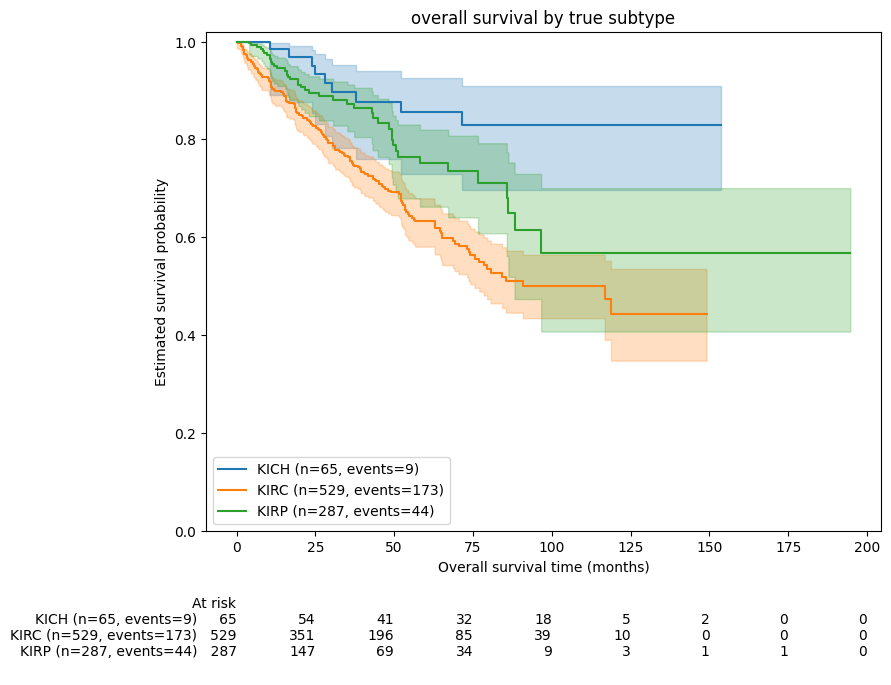


Survival analysis: overall_survival_by_true_subtype


,group,n,events,censored,median_overall_survival_months,meets_inference_thresholds
0,KICH,65,9,56,NaN,True
1,KIRC,529,173,356,116.76386,True
2,KIRP,287,44,243,NaN,True


,analysis_name,group_column,number_of_groups,test_statistic,p_value,minimum_group_n,minimum_group_events
0,overall_survival_by_true_subtype,class_label,3,23.457332,0.000008,10,3


,group_1,group_2,group_1_n,group_1_events,group_2_n,group_2_events,test_statistic,raw_p_value,bh_fdr_p_value,bh_fdr_significant_0_05
0,KICH,KIRC,65,9,529,173,14.998684,0.000108,0.000323,True
1,KICH,KIRP,65,9,287,44,4.811386,0.028272,0.028272,True
2,KIRC,KIRP,529,173,287,44,10.064729,0.001511,0.002267,True


In [ ]:
# ============================================================
# CELL 10: DESCRIPTIVE OVERALL SURVIVAL BY TRUE HISTOLOGY
# ============================================================

true_subtype_survival = (
    sample_metadata.reset_index()[
        ["case_submitter_id", "class_label", "data_split"]
    ]
    .merge(
        clinical_survival,
        on="case_submitter_id",
        how="left",
        validate="one_to_one",
    )
)
true_subtype_survival.to_csv(
    OUTPUT_DIR / "true_subtype_survival_data.csv",
    index=False,
)

true_subtype_survival_results = analyze_survival_groups(
    true_subtype_survival,
    group_column="class_label",
    analysis_name="overall_survival_by_true_subtype",
    output_directory=OUTPUT_DIR / "true_subtype_survival",
)


COMPLETE PIPELINE: primary_log2_tpm
NSGA preflight passed: vectorized Problem; objectives=[0.17263706331437867, 0.5857864376269049]

Starting NSGA-II: primary_log2_tpm
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      4 |             - |             -
     2 |      200 |      6 |  0.0381130851 |         ideal
     3 |      300 |      8 |  0.0250927487 |         nadir
     4 |      400 |     10 |  0.0072663038 |         ideal
     5 |      500 |     10 |  0.0160984853 |         ideal
     6 |      600 |     10 |  0.0037506158 |             f
     7 |      700 |     10 |  0.0009850728 |             f
     8 |      800 |     10 |  0.0009850728 |             f
     9 |      900 |     11 |  0.0102707654 |         ideal
    10 |     1000 |     11 |  0.000000E+00 |             f
    11 |     1100 |     12 |  0.0011110302 |             f
    12 |     1200 |     13 |  0.0017545725 |             f
    13 |     1300 |     13 |  0.0017545725 |             f
    1

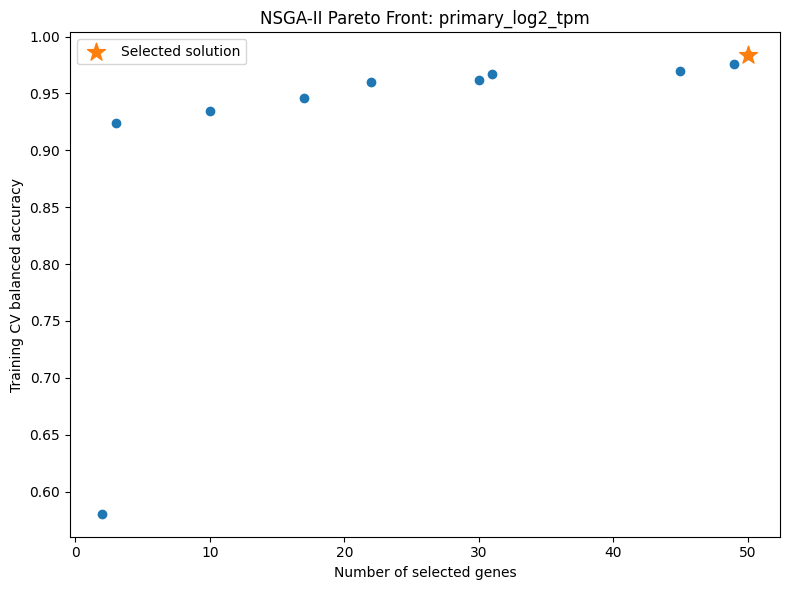

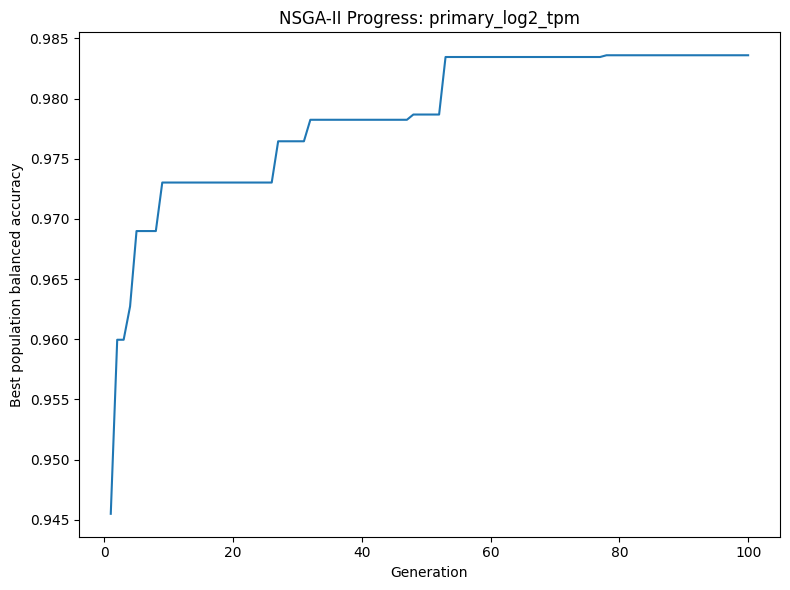

Selected 50 genes; CV balanced accuracy=0.9836; soft leanness=0.1239

Tuning final decision tree: primary_log2_tpm


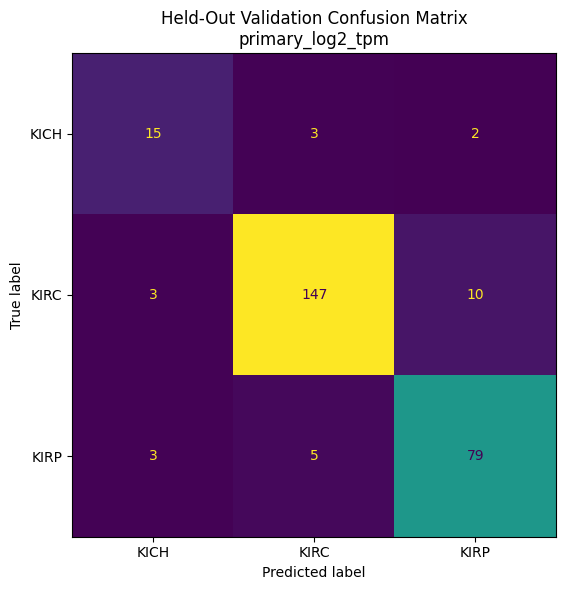

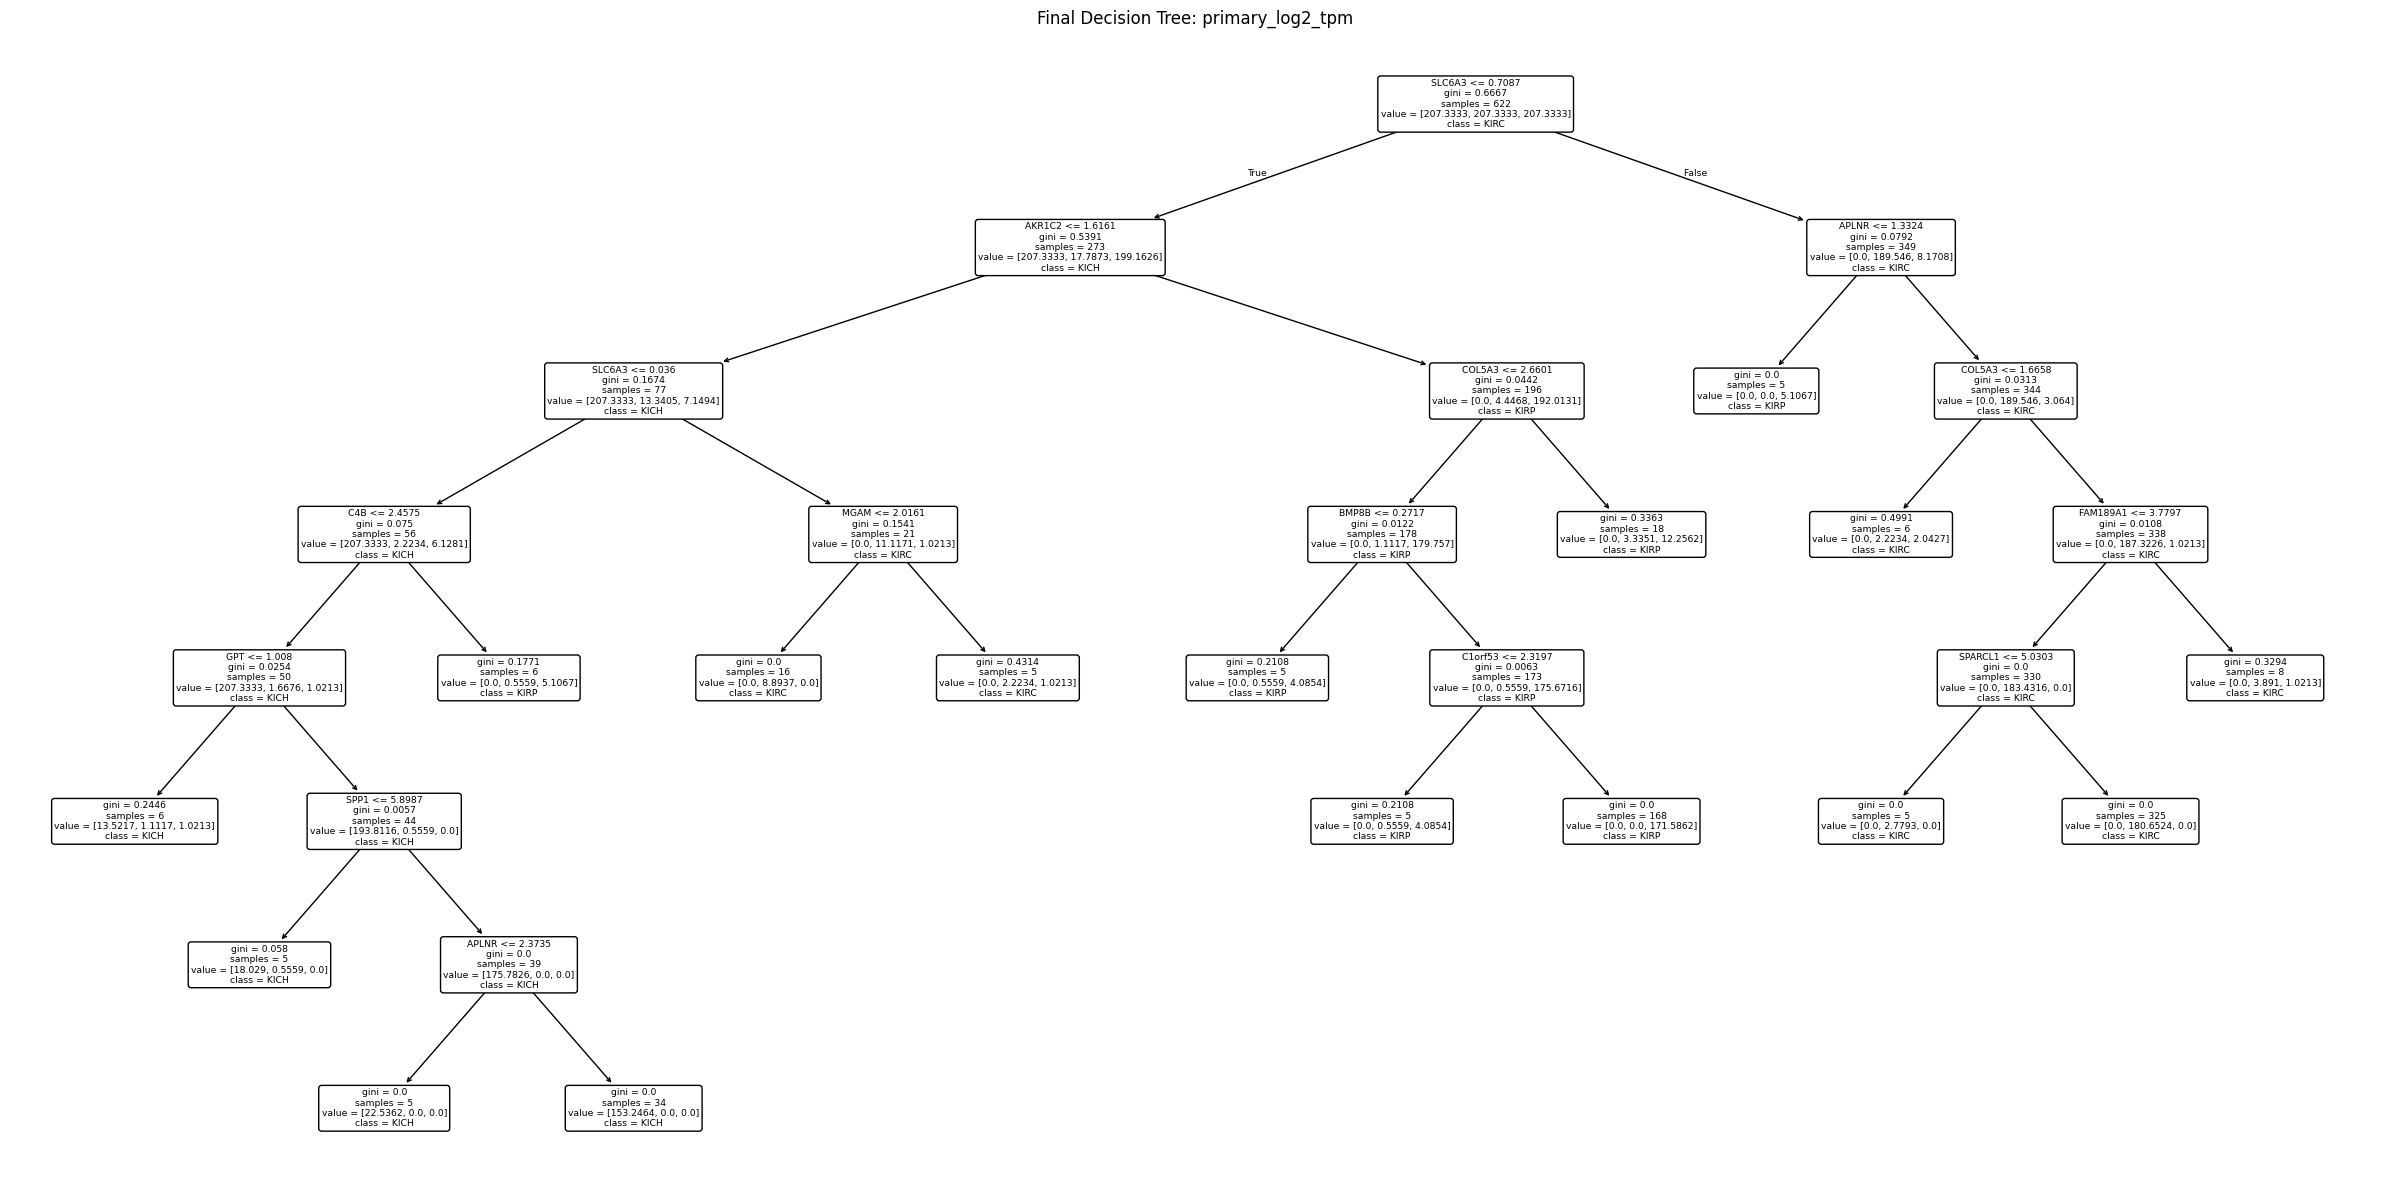

,dataset,n_patients,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_ovr_roc_auc,branch_name,selected_gene_count,tree_cv_best_balanced_accuracy
0,training,622,0.972669,0.981066,0.955188,0.981066,0.967502,0.972773,0.998317,primary_log2_tpm,50,0.946637
1,heldout_validation,267,0.902622,0.858932,0.843602,0.858932,0.850894,0.903342,0.909255,primary_log2_tpm,50,0.946637


,class_name,true_positive,false_negative,false_positive,true_negative,sensitivity,specificity,dataset,branch_name
0,KICH,46,0,4,572,1.000000,0.993056,training,primary_log2_tpm
1,KIRC,361,12,4,245,0.967828,0.983936,training,primary_log2_tpm
2,KIRP,198,5,9,410,0.975369,0.978520,training,primary_log2_tpm
3,KICH,15,5,6,241,0.750000,0.975709,heldout_validation,primary_log2_tpm
4,KIRC,147,13,8,99,0.918750,0.925234,heldout_validation,primary_log2_tpm
5,KIRP,79,8,12,168,0.908046,0.933333,heldout_validation,primary_log2_tpm


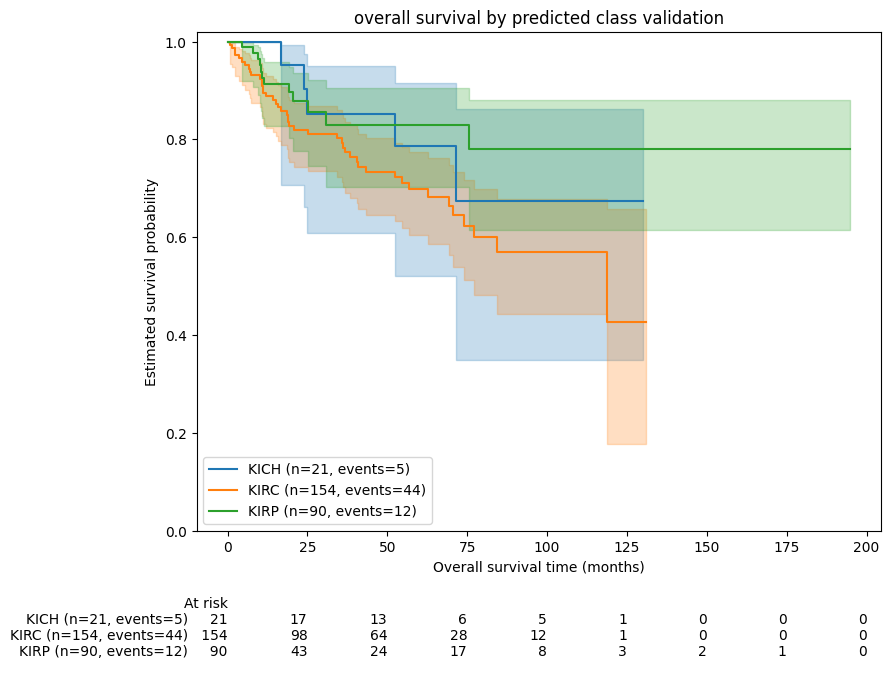


Survival analysis: overall_survival_by_predicted_class_validation


,group,n,events,censored,median_overall_survival_months,meets_inference_thresholds
0,KICH,21,5,16,NaN,True
1,KIRC,154,44,110,118.767967,True
2,KIRP,90,12,78,NaN,True


,analysis_name,group_column,number_of_groups,test_statistic,p_value,minimum_group_n,minimum_group_events
0,overall_survival_by_predicted_class_validation,predicted_class,3,4.385597,0.111604,10,3


,group_1,group_2,group_1_n,group_1_events,group_2_n,group_2_events,test_statistic,raw_p_value,bh_fdr_p_value,bh_fdr_significant_0_05
0,KICH,KIRC,21,5,154,44,0.908512,0.340509,0.510764,False
1,KICH,KIRP,21,5,90,12,0.116210,0.733182,0.733182,False
2,KIRC,KIRP,154,44,90,12,4.063588,0.043817,0.131452,False


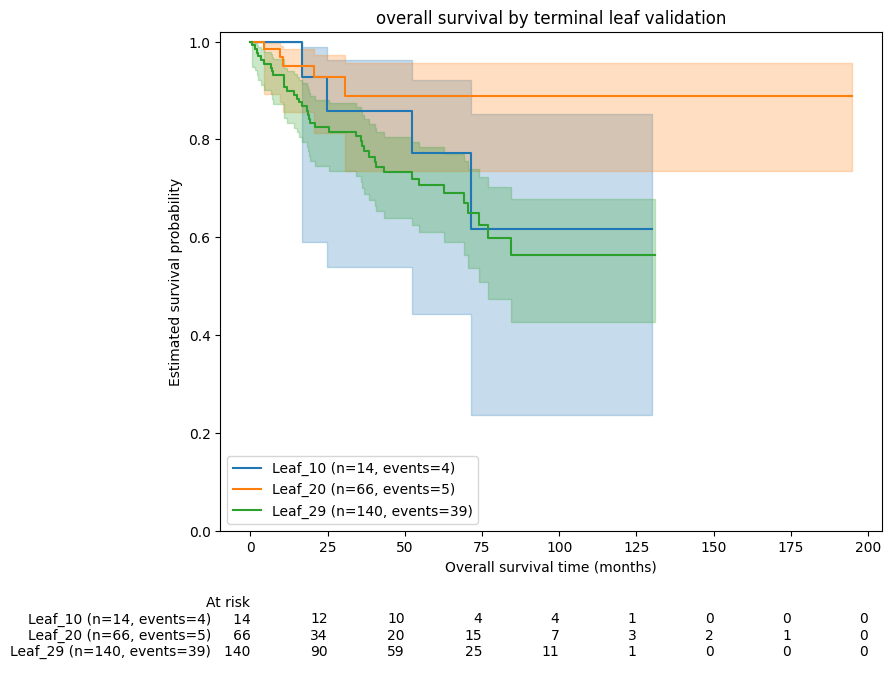


Survival analysis: overall_survival_by_terminal_leaf_validation


,group,n,events,censored,median_overall_survival_months,meets_inference_thresholds
0,Leaf_10,14,4,10,NaN,True
1,Leaf_11,3,0,3,NaN,False
2,Leaf_13,4,2,2,118.767967,False
3,Leaf_14,1,0,1,NaN,False
4,Leaf_17,9,2,7,NaN,False
5,Leaf_19,2,1,1,11.268994,False
6,Leaf_20,66,5,61,NaN,True
7,Leaf_21,8,4,4,25.232033,False
8,Leaf_23,2,0,2,NaN,False
9,Leaf_25,1,0,1,NaN,False


,analysis_name,group_column,number_of_groups,test_statistic,p_value,minimum_group_n,minimum_group_events
0,overall_survival_by_terminal_leaf_validation,terminal_leaf,3,7.394193,0.024795,10,3


,group_1,group_2,group_1_n,group_1_events,group_2_n,group_2_events,test_statistic,raw_p_value,bh_fdr_p_value,bh_fdr_significant_0_05
0,Leaf_10,Leaf_20,14,4,66,5,2.016172,0.155631,0.233447,False
1,Leaf_10,Leaf_29,14,4,140,39,0.259375,0.610550,0.610550,False
2,Leaf_20,Leaf_29,66,5,140,39,7.364551,0.006652,0.019957,True



COMPLETE PIPELINE: sensitivity_log2_cpm
NSGA preflight passed: vectorized Problem; objectives=[0.10423273617882745, 0.5857864376269049]

Starting NSGA-II: sensitivity_log2_cpm
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      8 |             - |             -
     2 |      200 |     11 |  0.0589248844 |         ideal
     3 |      300 |     13 |  0.0082938171 |         ideal
     4 |      400 |     14 |  0.0071541798 |         ideal
     5 |      500 |     14 |  0.000000E+00 |             f
     6 |      600 |     16 |  0.0395442752 |         ideal
     7 |      700 |     16 |  0.000000E+00 |             f
     8 |      800 |     16 |  0.000000E+00 |             f
     9 |      900 |     15 |  0.0020083878 |             f
    10 |     1000 |     15 |  0.0020083878 |             f
    11 |     1100 |     15 |  0.0020083878 |             f
    12 |     1200 |     16 |  0.0026364858 |             f
    13 |     1300 |     16 |  0.0155714061 |         ide

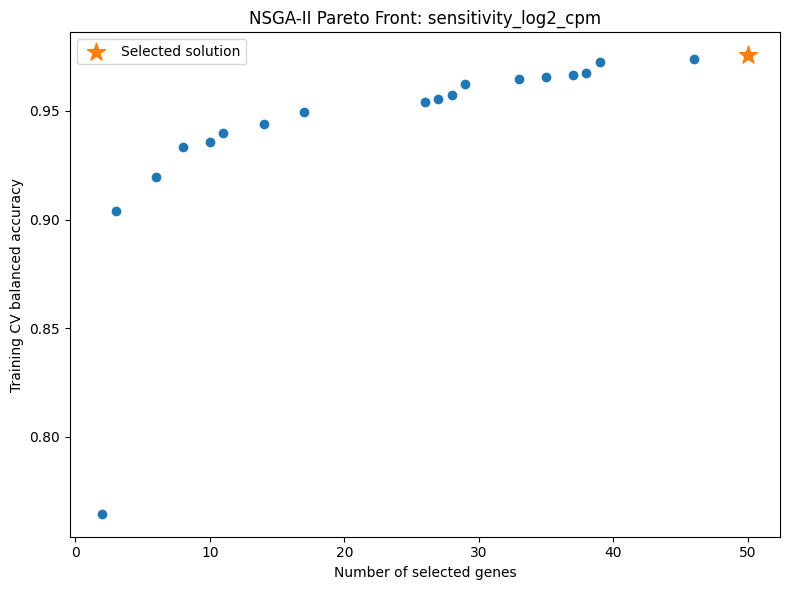

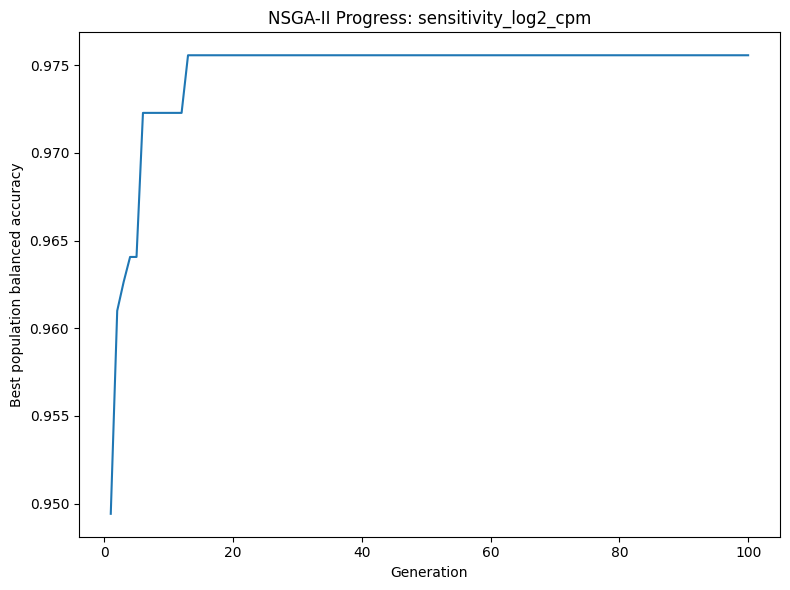

Selected 50 genes; CV balanced accuracy=0.9756; soft leanness=0.1239

Tuning final decision tree: sensitivity_log2_cpm


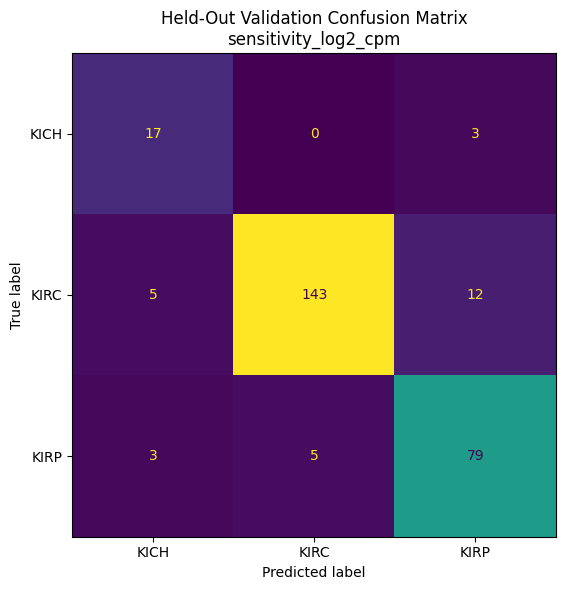

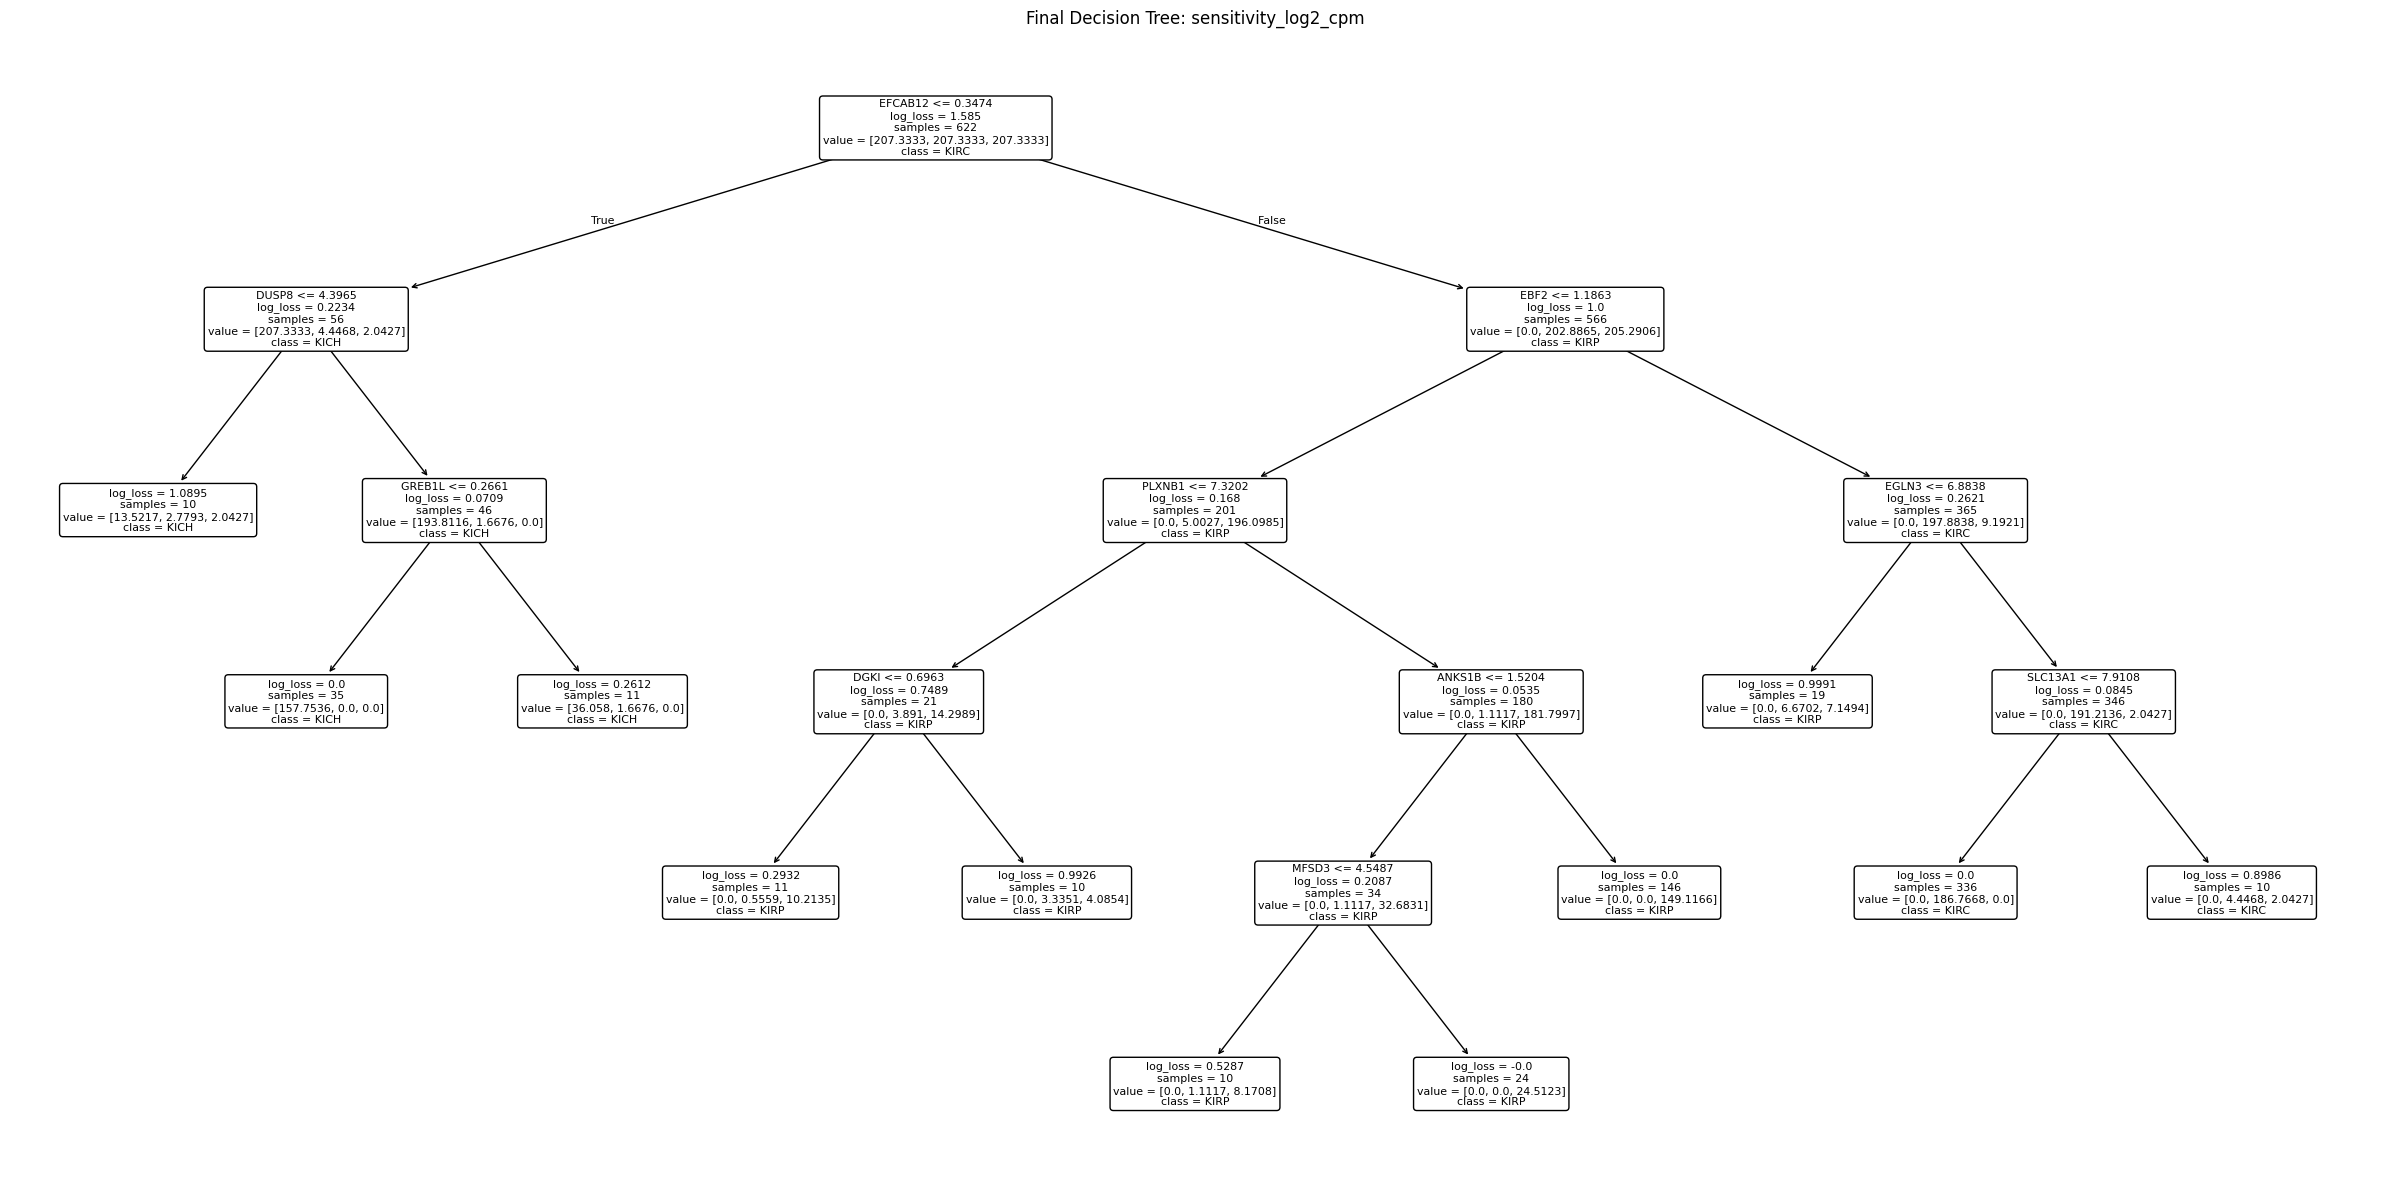

,dataset,n_patients,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_ovr_roc_auc,branch_name,selected_gene_count,tree_cv_best_balanced_accuracy
0,training,622,0.946945,0.967516,0.906731,0.967516,0.933248,0.947605,0.997081,sensitivity_log2_cpm,50,0.960282
1,heldout_validation,267,0.895131,0.883932,0.828881,0.883932,0.852352,0.897480,0.931438,sensitivity_log2_cpm,50,0.960282


,class_name,true_positive,false_negative,false_positive,true_negative,sensitivity,specificity,dataset,branch_name
0,KICH,46,0,10,566,1.000000,0.982639,training,sensitivity_log2_cpm
1,KIRC,344,29,2,247,0.922252,0.991968,training,sensitivity_log2_cpm
2,KIRP,199,4,21,398,0.980296,0.949881,training,sensitivity_log2_cpm
3,KICH,17,3,8,239,0.850000,0.967611,heldout_validation,sensitivity_log2_cpm
4,KIRC,143,17,5,102,0.893750,0.953271,heldout_validation,sensitivity_log2_cpm
5,KIRP,79,8,15,165,0.908046,0.916667,heldout_validation,sensitivity_log2_cpm


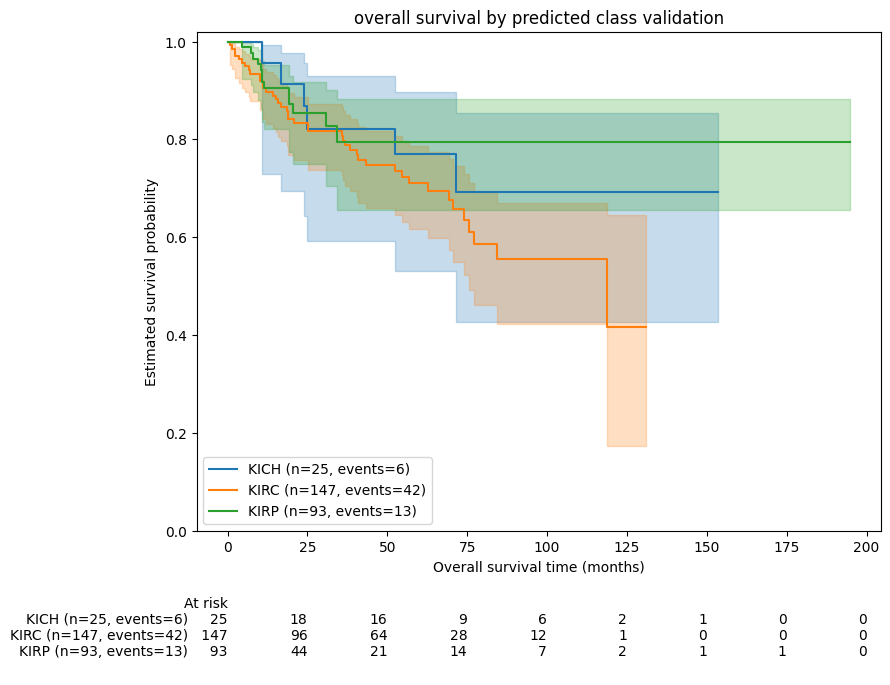


Survival analysis: overall_survival_by_predicted_class_validation


,group,n,events,censored,median_overall_survival_months,meets_inference_thresholds
0,KICH,25,6,19,NaN,True
1,KIRC,147,42,105,118.767967,True
2,KIRP,93,13,80,NaN,True


,analysis_name,group_column,number_of_groups,test_statistic,p_value,minimum_group_n,minimum_group_events
0,overall_survival_by_predicted_class_validation,predicted_class,3,3.213577,0.200531,10,3


,group_1,group_2,group_1_n,group_1_events,group_2_n,group_2_events,test_statistic,raw_p_value,bh_fdr_p_value,bh_fdr_significant_0_05
0,KICH,KIRC,25,6,147,42,1.058596,0.303536,0.455303,False
1,KICH,KIRP,25,6,93,13,0.127468,0.721072,0.721072,False
2,KIRC,KIRP,147,42,93,13,2.800625,0.094228,0.282683,False


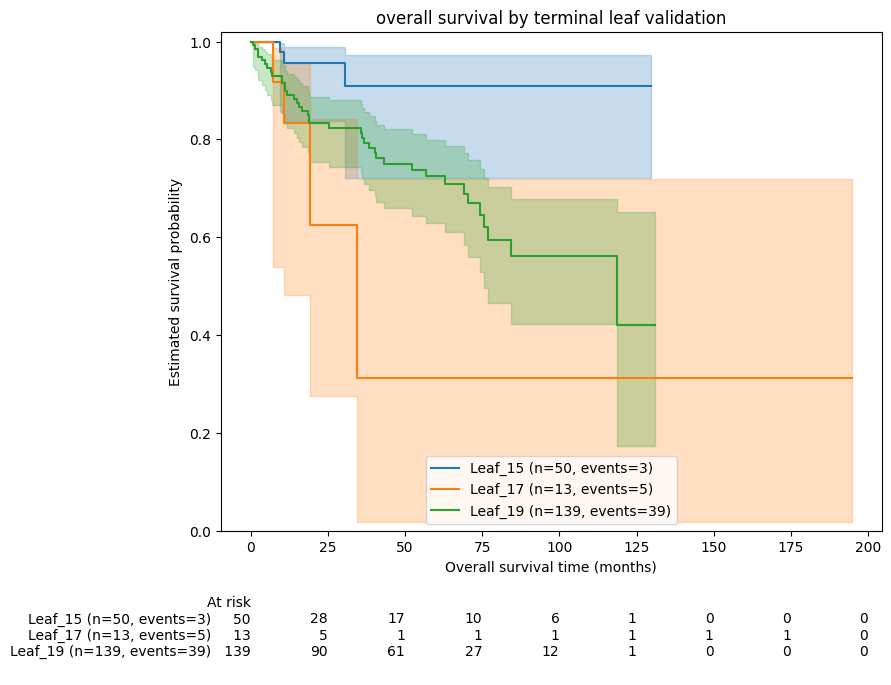


Survival analysis: overall_survival_by_terminal_leaf_validation


,group,n,events,censored,median_overall_survival_months,meets_inference_thresholds
0,Leaf_10,6,2,4,10.546201,False
1,Leaf_13,5,1,4,NaN,False
2,Leaf_14,12,1,11,NaN,False
3,Leaf_15,50,3,47,NaN,True
4,Leaf_17,13,5,8,34.332649,True
5,Leaf_19,139,39,100,118.767967,True
6,Leaf_2,7,4,3,52.238193,False
7,Leaf_20,8,3,5,54.570842,False
8,Leaf_4,12,1,11,NaN,False
9,Leaf_5,6,1,5,NaN,False


,analysis_name,group_column,number_of_groups,test_statistic,p_value,minimum_group_n,minimum_group_events
0,overall_survival_by_terminal_leaf_validation,terminal_leaf,3,10.964713,0.00416,10,3


,group_1,group_2,group_1_n,group_1_events,group_2_n,group_2_events,test_statistic,raw_p_value,bh_fdr_p_value,bh_fdr_significant_0_05
0,Leaf_15,Leaf_17,50,3,13,5,11.292828,0.000778,0.002334,True
1,Leaf_15,Leaf_19,50,3,139,39,7.681160,0.005580,0.008370,True
2,Leaf_17,Leaf_19,13,5,139,39,2.127284,0.144697,0.144697,False


All requested branches are complete.


In [11]:
# ============================================================
# CELL 11: RUN NSGA-II, FINAL TREE, AND SURVIVAL FOR EACH BRANCH
# ============================================================

all_branch_results = {}

for branch_name in BRANCHES_TO_RUN:
    print("\n" + "=" * 80)
    print(f"COMPLETE PIPELINE: {branch_name}")
    print("=" * 80)

    branch_data = loaded_branches[branch_name]

    # A. Wrapper feature selection using training data only.
    nsga_results = run_nsga_ii(branch_data)

    # B. Final interpretable tree and one held-out validation evaluation.
    tree_results = fit_final_decision_tree(branch_data, nsga_results)

    # C. Link model-defined groups to current GDC overall-survival data.
    survival_dir = OUTPUT_DIR / branch_name / "survival_analysis"
    survival_dir.mkdir(parents=True, exist_ok=True)

    model_survival_data = tree_results["assignments"].merge(
        clinical_survival,
        on="case_submitter_id",
        how="left",
        validate="one_to_one",
    )
    model_survival_data.to_csv(
        survival_dir / "decision_tree_assignments_with_survival.csv",
        index=False,
    )

    if MODEL_SURVIVAL_SCOPE == "validation":
        scope_data = model_survival_data.loc[
            model_survival_data["data_split"] == "validation"
        ].copy()
    elif MODEL_SURVIVAL_SCOPE == "all":
        scope_data = model_survival_data.copy()
    else:
        raise ValueError("MODEL_SURVIVAL_SCOPE must be 'validation' or 'all'.")

    predicted_class_survival = analyze_survival_groups(
        scope_data,
        group_column="predicted_class",
        analysis_name=(
            f"overall_survival_by_predicted_class_{MODEL_SURVIVAL_SCOPE}"
        ),
        output_directory=survival_dir,
    )

    terminal_leaf_survival = analyze_survival_groups(
        scope_data,
        group_column="terminal_leaf",
        analysis_name=(
            f"overall_survival_by_terminal_leaf_{MODEL_SURVIVAL_SCOPE}"
        ),
        output_directory=survival_dir,
    )

    all_branch_results[branch_name] = {
        "nsga_results": nsga_results,
        "tree_results": tree_results,
        "model_survival_data": model_survival_data,
        "predicted_class_survival": predicted_class_survival,
        "terminal_leaf_survival": terminal_leaf_survival,
    }

print("All requested branches are complete.")

In [12]:
# ============================================================
# CELL 12: COMPARE PRIMARY TPM WITH SENSITIVITY CPM
# ============================================================

comparison_records = []

for branch_name, results in all_branch_results.items():
    nsga_summary = results["nsga_results"]["run_summary"]
    validation_metrics = (
        results["tree_results"]["overall_metrics"]
        .loc[lambda frame: frame["dataset"] == "heldout_validation"]
        .iloc[0]
    )

    comparison_records.append(
        {
            "branch_name": branch_name,
            "nsga_selected_gene_count": nsga_summary["selected_number_of_genes"],
            "nsga_training_cv_balanced_accuracy": (
                nsga_summary["selected_cv_balanced_accuracy"]
            ),
            "nsga_soft_leanness": nsga_summary["selected_soft_leanness"],
            "decision_tree_validation_accuracy": validation_metrics["accuracy"],
            "decision_tree_validation_balanced_accuracy": (
                validation_metrics["balanced_accuracy"]
            ),
            "decision_tree_validation_macro_f1": validation_metrics["macro_f1"],
            "decision_tree_validation_macro_ovr_roc_auc": (
                validation_metrics["macro_ovr_roc_auc"]
            ),
        }
    )

branch_comparison = pd.DataFrame(comparison_records)
branch_comparison.to_csv(
    OUTPUT_DIR / "primary_tpm_vs_sensitivity_cpm_comparison.csv",
    index=False,
)
display(branch_comparison)

if {"primary_log2_tpm", "sensitivity_log2_cpm"}.issubset(all_branch_results):
    tpm_genes = set(
        all_branch_results["primary_log2_tpm"]["nsga_results"]["selected_gene_ids"]
    )
    cpm_genes = set(
        all_branch_results["sensitivity_log2_cpm"]["nsga_results"]["selected_gene_ids"]
    )
    intersection = tpm_genes & cpm_genes
    union = tpm_genes | cpm_genes

    overlap_table = (
        pd.DataFrame({"gene_id": sorted(intersection)})
        .merge(
            gene_annotation[["gene_id", "gene_name", "gene_type"]],
            on="gene_id",
            how="left",
        )
    )
    overlap_table.to_csv(
        OUTPUT_DIR / "nsga_selected_gene_overlap_tpm_cpm.csv",
        index=False,
    )

    overlap_summary = pd.DataFrame(
        [
            {
                "primary_tpm_selected_genes": len(tpm_genes),
                "sensitivity_cpm_selected_genes": len(cpm_genes),
                "intersection_count": len(intersection),
                "union_count": len(union),
                "jaccard_similarity": (
                    len(intersection) / len(union) if union else np.nan
                ),
            }
        ]
    )
    overlap_summary.to_csv(
        OUTPUT_DIR / "nsga_selected_gene_overlap_summary.csv",
        index=False,
    )
    display(overlap_summary)
    display(overlap_table)

print("\nOutput files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(OUTPUT_DIR))

,branch_name,nsga_selected_gene_count,nsga_training_cv_balanced_accuracy,nsga_soft_leanness,decision_tree_validation_accuracy,decision_tree_validation_balanced_accuracy,decision_tree_validation_macro_f1,decision_tree_validation_macro_ovr_roc_auc
0,primary_log2_tpm,50,0.983602,0.123899,0.902622,0.858932,0.850894,0.909255
1,sensitivity_log2_cpm,50,0.975559,0.123899,0.895131,0.883932,0.852352,0.931438


,primary_tpm_selected_genes,sensitivity_cpm_selected_genes,intersection_count,union_count,jaccard_similarity
0,50,50,0,100,0.0


,gene_id,gene_name,gene_type



Output files:
gdc_tcga_kidney_overall_survival.csv
nsga_selected_gene_overlap_summary.csv
nsga_selected_gene_overlap_tpm_cpm.csv
primary_log2_tpm/decision_tree.png
primary_log2_tpm/decision_tree_best_parameters.json
primary_log2_tpm/decision_tree_cv_grid_results.csv
primary_log2_tpm/decision_tree_feature_importance.csv
primary_log2_tpm/decision_tree_leaf_rules.csv
primary_log2_tpm/decision_tree_overall_metrics.csv
primary_log2_tpm/decision_tree_patient_assignments.csv
primary_log2_tpm/decision_tree_per_class_metrics.csv
primary_log2_tpm/decision_tree_rules.txt
primary_log2_tpm/decision_tree_training_classification_report.csv
primary_log2_tpm/decision_tree_validation_classification_report.csv
primary_log2_tpm/decision_tree_validation_confusion_matrix.png
primary_log2_tpm/nsga_ii_final_selected_genes.csv
primary_log2_tpm/nsga_ii_pareto_front.csv
primary_log2_tpm/nsga_ii_pareto_front.png
primary_log2_tpm/nsga_ii_progress.csv
primary_log2_tpm/nsga_ii_progress.png
primary_log2_tpm/nsga_ii_

## Interpretation safeguards

- The final classification result is the decision tree's performance on the untouched held-out validation cohort.
- The CPM analysis is a sensitivity analysis using the identical patients and split as the primary TPM analysis.
- Model-defined survival comparisons are exploratory because the groups originate from these TCGA cohorts.
- Terminal-node inference is restricted to groups with at least 10 patients and at least 3 observed deaths.
- External validation is still required before claiming general clinical validity.

In [ ]:
import shutil
from google.colab import files

output_folder = (
    "/content/drive/MyDrive/"
    "TCGA_Kidney_RNASeq/modeling_outputs"
)

zip_path = shutil.make_archive(
    "/content/TCGA_Kidney_modeling_outputs",
    "zip",
    output_folder,
)

print(f"Created: {zip_path}")
files.download(zip_path)